In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import pandas as pd
import seaborn as sns

from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

from Transformer import TransformerClassifier, MyDataset, create_padding_mask

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
raw_train_data = torch.load("Train_data_h2",weights_only = True)
raw_train_classes = torch.load("Train_classes_h2",weights_only = True)

raw_test_data = torch.load("Test_data_G",weights_only=True)
raw_test_classes = torch.load("Test_classes_G",weights_only=True)

In [4]:
raw_test_classes.shape, sum(raw_test_classes)

(torch.Size([4345, 1]), tensor([1305]))

In [5]:
raw_train_classes.shape, sum(raw_train_classes)

(torch.Size([2940, 1]), tensor([1464.]))

In [6]:
train_data = raw_train_data.float().to(device)
test_data = raw_test_data.float().to(device)
train_classes = raw_train_classes.float().to(device)
test_classes = raw_test_classes.float().to(device)


train_data.shape, train_classes.shape, test_data.shape, test_classes.shape

(torch.Size([2940, 600, 12]),
 torch.Size([2940, 1]),
 torch.Size([4345, 600, 12]),
 torch.Size([4345, 1]))

In [7]:
if torch.isnan(raw_train_data).any():
    print("Input tensor contains NaN values!")
    print(f"{torch.isnan(raw_train_data).sum().item()} NaNs")
else:
    print("Inputs good")

if torch.isinf(raw_train_data).any():
    print("Input tensor contains Inf values!")
    print(f"{torch.isinf(raw_train_data).sum().item()} Infs")
else:
    print("Inputs good")

Inputs good
Inputs good


In [8]:
if torch.isnan(raw_test_data).any():
    print("Input tensor contains NaN values!")
    print(f"{torch.isnan(raw_test_data).sum().item()} NaNs")
else:
    print("Inputs good")

if torch.isinf(raw_test_data).any():
    print("Input tensor contains Inf values!")
    print(f"{torch.isinf(raw_test_data).sum().item()} Infs")
else:
    print("Inputs good")

Inputs good
Inputs good


In [9]:
train_dataset = MyDataset(train_data, train_classes)
test_dataset = MyDataset(test_data, test_classes)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=True)

In [10]:
epochs = 75
models = []
train_losses = []
test_losses = []
test_accuracies = []

dim_feedforward = 12
input_dim = 12  # Number of features
d_model = 12  # Transformer model dimension
num_heads = 4   # Number of attention heads
num_layers = 2  # Number of transformer layers
dropout = 0.2   # Dropout rate

model = TransformerClassifier(input_dim, d_model, num_heads, num_layers, dim_feedforward, dropout).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.00005)
criterion = nn.BCEWithLogitsLoss()
model.train()


for epoch in range(1,epochs+1):

    model.train()
    running_loss = 0.0
    num_batches = 0

    for batch_data, batch_labels in train_dataloader:
        output = model(batch_data)      
        loss = criterion(output, batch_labels)
        optimizer.zero_grad()  
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        num_batches += 1
    
    epoch_loss = running_loss / num_batches
    print(f"epoch {epoch} loss: {epoch_loss}")
    train_losses.append(epoch_loss)

    test_result = []
    
    model.eval()
    running_test_loss = 0.0
    num_test_batches = 0
    with torch.no_grad():
        for batch_test_data, batch_test_labels in test_dataloader:
            test_output = model(batch_test_data)
            test_loss = criterion(test_output,batch_test_labels)
            running_test_loss += test_loss.item()
            num_test_batches += 1
            test_probability = torch.sigmoid(test_output)
            test_prediction = torch.round(test_probability)
            test_result.append((test_prediction==batch_test_labels).float())

    epoch_test_loss = running_test_loss / num_test_batches
    test_losses.append(epoch_test_loss)
    
    t_result = torch.cat(test_result)
    test_accuracy = (sum(t_result).cpu().numpy())/len(t_result)
    test_accuracies.append(test_accuracy)

c:\Users\a3ebadi\.conda\envs\x\lib\site-packages\torch\nn\functional.py:5560: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


epoch 1 loss: 0.7006640654543171
epoch 2 loss: 0.68713905889055
epoch 3 loss: 0.6758160928021306
epoch 4 loss: 0.667189073951348
epoch 5 loss: 0.6596396973599559
epoch 6 loss: 0.653218792832416
epoch 7 loss: 0.6476608449998109
epoch 8 loss: 0.6421228511177975
epoch 9 loss: 0.6378196426059889
epoch 10 loss: 0.6337130477894908
epoch 11 loss: 0.6296954252149748
epoch 12 loss: 0.6261131549658983
epoch 13 loss: 0.6224210638066997
epoch 14 loss: 0.6189307972140934
epoch 15 loss: 0.6147310432532559
epoch 16 loss: 0.6112603457725566
epoch 17 loss: 0.6087134146819944
epoch 18 loss: 0.6054571167282436
epoch 19 loss: 0.6019039808408074
epoch 20 loss: 0.5990446112726046
epoch 21 loss: 0.5953027806852175
epoch 22 loss: 0.59216148438661
epoch 23 loss: 0.5892432902170264
epoch 24 loss: 0.586120222573695
epoch 25 loss: 0.5842391450120055
epoch 26 loss: 0.5812379452197448
epoch 27 loss: 0.5785894222233606
epoch 28 loss: 0.5764007118085156
epoch 29 loss: 0.5742795153156571
epoch 30 loss: 0.5714846554657

In [11]:
t_result.shape

torch.Size([4345, 1])

In [12]:
sum(t_result).cpu().numpy()

array([3849.], dtype=float32)

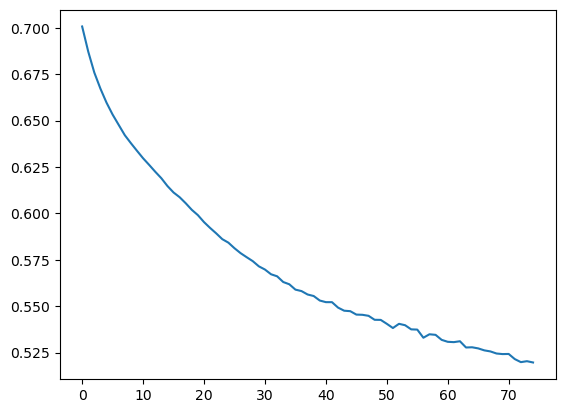

In [13]:
plt.plot(train_losses)

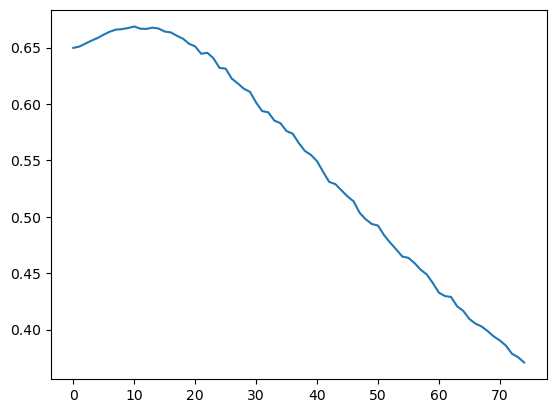

In [14]:
plt.plot(test_losses)

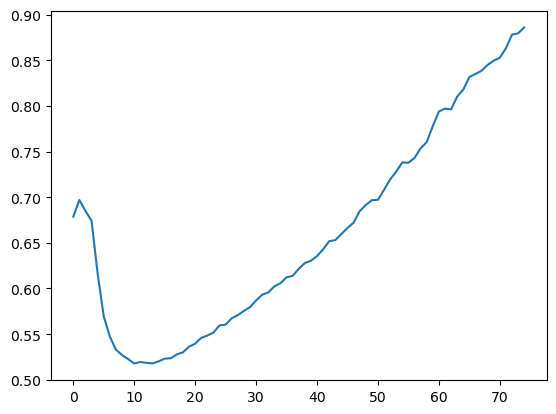

In [15]:
plt.plot(test_accuracies)

ROC Curve Generation

In [17]:
probabilities = []
predictions = []
true_labels = []

model.eval()
with torch.no_grad():
        for batch_test_data, batch_test_labels in test_dataloader:
            test_output = model(batch_test_data)
            test_probability = torch.sigmoid(test_output)
            probabilities.append(test_probability)
            test_pred = torch.round(test_probability)
            predictions.append(test_pred)
            true_labels.append(batch_test_labels)

y_pred = torch.cat(predictions).cpu().numpy()
y_prob = torch.cat(probabilities).cpu().numpy()
y_true = torch.cat(true_labels).cpu().numpy()

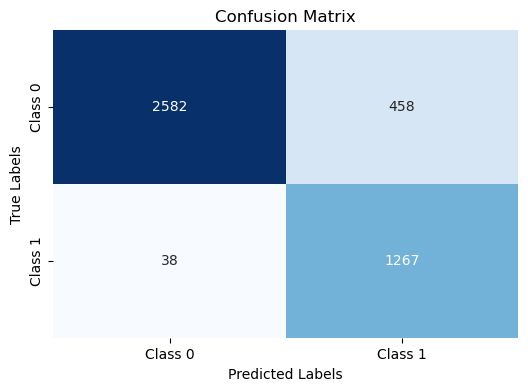

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Add labels, title, and axis ticks
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix')

# Add custom class labels (optional, if binary classification)
ax.xaxis.set_ticklabels(['Class 0', 'Class 1'])
ax.yaxis.set_ticklabels(['Class 0', 'Class 1'])

plt.show()

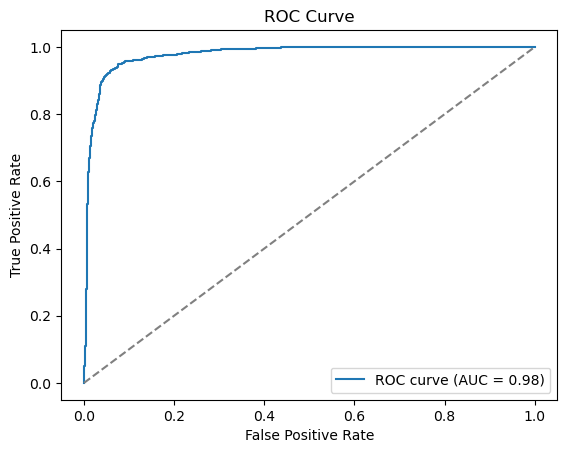

In [19]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [20]:
for name,param in model.named_parameters():
    print(name,param,param.shape)

projection.weight Parameter containing:
tensor([[-0.3645,  0.2378, -0.0876,  0.2480, -0.2234,  0.3243, -0.1966, -0.2275,
         -0.3384, -0.2978, -0.0123, -0.0863],
        [ 0.2427,  0.1411,  0.0327, -0.0563,  0.0391,  0.0041,  0.0209,  0.1541,
          0.3479, -0.2982, -0.1656, -0.2036],
        [ 0.3542, -0.0846, -0.2797, -0.0571, -0.1893, -0.1881, -0.2736,  0.0433,
         -0.0448,  0.0635,  0.3864, -0.1737],
        [ 0.0382,  0.1487,  0.1278,  0.2536, -0.1419, -0.1288, -0.1371,  0.0366,
          0.2013,  0.2423,  0.0908,  0.1676],
        [ 0.4214,  0.2035, -0.0206, -0.1921,  0.1423,  0.1488,  0.2901, -0.0923,
          0.0775,  0.5941,  0.1153,  0.1978],
        [ 0.0463, -0.1596, -0.0043, -0.0830,  0.0245, -0.1532, -0.0465, -0.1789,
          0.3007,  0.0657,  0.0877, -0.0890],
        [ 0.2177,  0.1074, -0.1016, -0.0982,  0.0764,  0.1558,  0.3287,  0.0359,
          0.2193,  0.1755, -0.1134,  0.3427],
        [-0.0427, -0.1253, -0.1768,  0.2979, -0.1032,  0.1022,  0.0272,

In [21]:
sum(y_true), sum(y_pred)

(array([1305.], dtype=float32), array([1725.], dtype=float32))

In [22]:
torch.save(model, 'modele75d2.pth')